In [1]:
# Rotation of Hacat cells
import os
# os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"

import cv2
import glob
import matplotlib.pyplot as plt
import numpy as np
from natsort import natsorted
from scipy.ndimage import rotate, gaussian_filter
from scipy.stats import circmean
import sys, time,random
from pathlib import Path
from PIL import Image
from joblib import Parallel, delayed
# from cellpose.io import imread
from cellpose import models, io
from skimage.measure import label, regionprops, regionprops_table
# from sklearn.neighbors import KDTree
from scipy.spatial.distance import pdist, squareform
# import statsmodels.api as sm


sys.path.append('../defect_functions') 
from defect_pairs import * 
from average_flows import * 

sys.path.append('../cell_tracking_functions') 
from segmentation import * 

import btrack
from btrack import datasets
import napari
import matplotlib.pyplot as plt
import tifffile
from skimage.io import imread

class Tracklet: # A generic custom class example
    def __init__(self, track_id, x_coords, y_coords, frames):
        self.track_id = track_id
        self.x = x_coords
        self.y = y_coords
        self.t = frames
    
    def __repr__(self):
        return f'Tracklet(ID={self.track_id}, points={len(self.x)})'



Welcome to CellposeSAM, cellpose v
cellpose version: 	4.0.6 
platform:       	win32 
python version: 	3.10.18 
torch version:  	2.8.0+cu126! The neural network component of
CPSAM is much larger than in previous versions and CPU excution is slow. 
We encourage users to use GPU/MPS if available. 




In [2]:
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\c3_6well_5min_10x\Pos11"
# path = r"C:\Users\victo\OneDrive - BGU\DATA\HBEC\s2"
mask_list = natsorted(glob.glob(path + r"\Mask\*.tif"), key=lambda y: y.lower())
masks = np.array([cv2.imread(mask, cv2.COLOR_RGB2GRAY)[:, :] for mask in mask_list])   

In [3]:
len(mask_list)

50

In [4]:
CONFIG_FILE = datasets.cell_config()
SEGMENTATION_FILE = datasets.example_segmentation_file()
OBJECTS_FILE = datasets.example_track_objects_file()
FEATURES = ["area", "major_axis_length", "minor_axis_length", "orientation", "solidity"]

# segmentation = tifffile.imread(SEGMENTATION_FILE)[:50]
# segmentation = imread(SEGMENTATION_FILE)[:50]

objects = btrack.utils.segmentation_to_objects(
    masks,
    properties=tuple(FEATURES),
    # num_workers=4,  # parallelise this
)

[INFO][2026/01/25 07:15:26 PM] Localizing objects from segmentation...
progress: 100%|██████████| 50/50 [00:11<00:00,  4.21it/s]
[INFO][2026/01/25 07:15:38 PM] Objects are of type: <class 'dict'>
[INFO][2026/01/25 07:15:38 PM] ...Found 8602 objects in 50 frames.


In [5]:
# import json

# with open(datasets.cell_config(), 'r') as file:
#     data = json.load(file)
# print(data)   

In [6]:
# initialise a tracker session using a context manager
with btrack.BayesianTracker() as tracker:
    # configure the tracker using a config file
    tracker.configure(CONFIG_FILE)
    tracker.max_search_radius = 30
    tracker.tracking_updates = ["MOTION", "VISUAL"]
    tracker.features = FEATURES

    # append the objects to be tracked
    tracker.append(objects)

    # set the tracking volume
    tracker.volume = ((0, masks.shape[-1]), (0, masks.shape[-2]))

    # track them (in interactive mode)
    tracker.track(step_size=100)

    # generate hypotheses and run the global optimizer
    tracker.optimize()

    # get the tracks in a format for napari visualization
    data, properties, graph = tracker.to_napari()

    # store the tracks
    tracks = tracker.tracks

    # store the configuration
    cfg = tracker.configuration

    # export the track data
    # tracker.export("tracks.h5", obj_type="obj_type_1")

[INFO][2026/01/25 07:15:38 PM] Loaded btrack: C:\Users\victo\miniconda3\envs\cellpose41\Lib\site-packages\btrack\libs\libtracker.DLL
[INFO][2026/01/25 07:15:38 PM] Starting BayesianTracker session
[INFO][2026/01/25 07:15:38 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\cell_config.json
[INFO][2026/01/25 07:15:38 PM] Objects are of type: <class 'list'>
[INFO][2026/01/25 07:15:38 PM] Starting tracking... 
[INFO][2026/01/25 07:15:38 PM] Update using: ['MOTION', 'VISUAL']
[INFO][2026/01/25 07:15:38 PM] Tracking objects in frames 0 to 50 (of 50)...
[INFO][2026/01/25 07:15:39 PM]  - Timing (Bayesian updates: 3.00ms, Linking: 1.00ms)
[INFO][2026/01/25 07:15:39 PM]  - Probabilities (Link: 1.00000, Lost: 1.00000)
[INFO][2026/01/25 07:15:39 PM] SUCCESS.
[INFO][2026/01/25 07:15:39 PM]  - Found 516 tracks in 50 frames (in 0.0s)
[INFO][2026/01/25 07:15:39 PM]  - Inserted 393 dummy objects to fill tracking gaps
[INFO][2026/01/25 07:15:39 

In [ ]:
viewer = napari.Viewer()
# # path = r"C:\Users\victo\OneDrive - BGU\BEER\Gil\tracks"
path = r"C:\Users\victo\OneDrive - BGU\DATA\HT1080\c3_6well_5min_10x\Pos4"
mask_list = natsorted(glob.glob(path + r"\Mask\*.tif"), key=lambda y: y.lower())
image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
masks = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY) for im in mask_list]) #[300:1000, 500:1200]
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)for im in image_list[:len(masks)]]) 

viewer.add_image(
    # segmentation,
    masks,
    name="Segmentation",
    opacity=0.2,
)

viewer.add_image(
    # segmentation,
    raws,
    name="Raw",
    opacity=0.2,
)

# # the track data from the tracker
# viewer.add_tracks(
#     data,
#     properties=properties,
#     graph=graph,
#     name="Tracks",
#     blending="translucent",
#     visible=True,
# )

<Image layer 'Raw' at 0x1d473a6ee60>

c:\Users\victo\miniconda3\envs\cellpose41\lib\site-packages\napari\layers\_layer_actions.py:86: UserWarning: projection mode "none" is not compatible with Labels layers. Falling back to "none".
  warnings.warn(
[INFO][2026/01/25 07:20:42 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\cell_config.json
[INFO][2026/01/25 07:20:42 PM] Loading configuration file: C:\Users\victo\AppData\Local\btrack-examples\btrack-examples\Cache\examples\particle_config.json


In [ ]:
# Extract tracks from Viewer
tracks_data = viewer.layers['Segmentation_btrack'].data
df = pd.DataFrame(tracks_data, columns=['track_id', 't', 'y', 'x'])

# Group by track ID and calculate displacement
track_stats = df.groupby('track_id').agg({
    'x': ['first', 'last'],
    'y': ['first', 'last'],
    't': 'count'
}).reset_index()

track_stats.columns = ['track_id', 'x_start', 'x_end', 'y_start', 'y_end', 'num_points']

# Calculate total displacement
track_stats['displacement'] = np.sqrt(
    (track_stats['x_end'] - track_stats['x_start'])**2 + 
    (track_stats['y_end'] - track_stats['y_start'])**2
)

# Filter for long moving tracks (adjust threshold as needed)
min_displacement = 50
long_tracks = track_stats[track_stats['displacement'] > min_displacement]['track_id'].values

df_long_tracks = df[df['track_id'].isin(long_tracks)].copy()

viewer.add_tracks(
    df_long_tracks[['track_id', 't', 'y', 'x']].to_numpy(),
)

In [11]:
df_list = []
for frame, mask in enumerate(masks):
    # Calculate neighbors
    neighbors = calculate_neighbors(mask)
    

    # Create DataFrame
    df_neighbors = create_dataframe(neighbors)
    df_neighbors["frame"] = frame
    df_list.append(df_neighbors)
    # break

features = pd.concat(df_list, ignore_index=True)

In [22]:
search_range = 30 #15
t = tp.link_df(features, search_range, memory=2)

Frame 51: 198 trajectories present.


In [19]:
t


,Cell,x,y,Area,Perimeter,Neighbors Num,Neighbors,frame,particle
0,1,259.412072,18.381520,1342.0,139.840620,0,[],0,0
17,18,218.770707,96.571717,990.0,122.497475,2,"[20, 12]",0,1
18,19,1135.039978,117.708105,1826.0,176.953319,0,[],0,2
67,68,264.246328,389.396987,2655.0,218.166522,1,[72],0,3
68,69,357.513208,415.926415,3710.0,271.965512,1,[72],0,4
...,...,...,...,...,...,...,...,...,...
9742,197,1208.992920,1095.532743,565.0,100.284271,0,[],51,594
9743,198,1496.394040,1099.294702,302.0,88.041631,0,[],51,72
9744,199,318.315789,1100.355263,152.0,57.556349,0,[],51,527
9713,168,125.523399,986.647934,5107.0,364.391919,2,"[166, 167]",51,584


In [27]:
t_filt = t[
    (t['Neighbors Num']==0)&(t['x']>50)&(t['x']<t['x'].max()-50)&(t['y']>50)&(t['y']<t['y'].max()-50)
    ].copy()

In [ ]:
# # the track data from the tracker
# viewer.add_tracks(
#     t[['particle','frame','y','x']].to_numpy(),
#     properties = t,
#     # graph=graph,
#     name="TrackPy",
#     blending="translucent",
#     visible=True,
# )

# the track data from the tracker
viewer.add_tracks(
    t_filt[['particle','frame','y','x']].to_numpy(),
    properties = t_filt,
    # graph=graph,
    name="TrackPy_filt",
    blending="translucent",
    visible=True,
)

[DEBUG][2026/01/25 07:39:42 PM] Not selecting new layer TrackPy_filt [4] as input for the segmentation widget as TrackPy_filt [4] is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.
[DEBUG][2026/01/25 07:39:42 PM] Not selecting new layer TrackPy_filt [4] as input for the segmentation widget as TrackPy_filt [4] is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.


<Tracks layer 'TrackPy_filt [4]' at 0x1d469213af0>

In [38]:
df_filt = t_filt.copy()
df_filt = df_filt.groupby('particle').filter(lambda x: len(x)>10).copy()
df_filt["step_ang"] = (np.atan2(df_filt.groupby('particle')['y'].diff(1),
         df_filt.groupby('particle')['x'].diff(1) ))
df_filt.hist(column='step_ang', bins=30)

array([[<Axes: title={'center': 'step_ang'}>]], dtype=object)

In [37]:
# the track data from the tracker
viewer.add_tracks(
    df_filt[['particle','frame','y','x']].to_numpy(),
    properties = df_filt,
    # graph=graph,
    name="TrackPy_filt",
    blending="translucent",
    visible=True,
)

[DEBUG][2026/01/25 07:42:40 PM] Not selecting new layer TrackPy_filt [5] as input for the segmentation widget as TrackPy_filt [5] is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.
[DEBUG][2026/01/25 07:42:40 PM] Not selecting new layer TrackPy_filt [5] as input for the segmentation widget as TrackPy_filt [5] is <class 'napari.layers.tracks.tracks.Tracks'> layer not an Labels layer.


<Tracks layer 'TrackPy_filt [5]' at 0x1d461d6ebc0>

In [ ]:
# Save viewer to video

from napari_animation import Animation
# Create an animation object
animation = Animation(viewer)

# Capture keyframes programmatically
# Example: go from slice 0 to slice 49 in 100 steps
viewer.dims.set_point(0, 0) # Set first dimension to first frame
animation.capture_keyframe(steps=100) # Capture starting state

viewer.dims.set_point(0, 49) # Set first dimension to last frame
animation.capture_keyframe(steps=100) # Capture ending state

# Animate and save all frames to a video file
# The format is inferred from the file extension
output_path = r"C:\Users\victo\Downloads\test2.mp4"
animation.animate(output_path, fps=20)

Rendering frames...


100%|██████████| 101/101 [00:11<00:00,  8.49it/s]


### DataFrame Option

In [41]:
df = pd.concat([pd.DataFrame(track.to_dict()) for track in tracks])

In [43]:
df['t'].max()

np.int64(49)

In [9]:
# tracklets = [
#     Tracklet(
#         track_id=row['ID'],
#         x_coords=row['x'],
#         y_coords=row['y'],
#         frames=row['t']
#     ) 
#     for index, row in df.iterrows()
# ]

In [10]:
df['track length_x'] = df.groupby('ID')['x'].transform(lambda x: x.iloc[-1] - x.iloc[0])
df['track length_y'] = df.groupby('ID')['y'].transform(lambda y: y.iloc[-1] - y.iloc[0])
df['track length'] = ((df['track length_x']) ** 2 + (df['track length_y']) ** 2) ** 0.5

<Axes: >

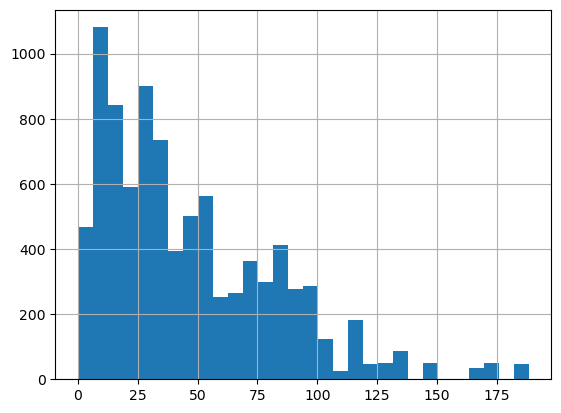

In [11]:
df['track length'].hist(bins=30)

In [15]:
from sklearn.neighbors import BallTree

def filter_isolated_tracks(df, min_dist, pos_cols=['x', 'y']):
    """
    Filters tracks in a DataFrame where all particles in the track have a 
    nearest neighbor distance greater than min_dist within the same time frame.
    """
    
    # Use .copy() when creating the temporary column assignment 
    # to avoid SettingWithCopyWarning if 'df' was created via slicing earlier.
    temp_df = df.copy() 
    
    temp_df['nearest_neighbor_dist'] = np.inf
    
    for t, frame_group in temp_df.groupby('t'):
        if len(frame_group) > 1:
            coords = frame_group[pos_cols].values
            tree = BallTree(coords)
            distances, indices = tree.query(coords, k=2)
            nn_distances = distances[:, 1]
            
            # Update each row directly to avoid index alignment issues
            for i, (idx, row) in enumerate(frame_group.iterrows()):
                temp_df.at[idx, 'nearest_neighbor_dist'] = nn_distances[i]

    temp_df['is_isolated_frame'] = temp_df['nearest_neighbor_dist'] > min_dist
    isolated_track_ids = temp_df.groupby('ID')['is_isolated_frame'].all()
    isolated_track_ids = isolated_track_ids[isolated_track_ids].index.tolist()
    
    filtered_df = temp_df[temp_df['ID'].isin(isolated_track_ids)].copy()
    
    # Drop the temporary columns from the result
    filtered_df = filtered_df.drop(columns=['nearest_neighbor_dist', 'is_isolated_frame'])
    
    return filtered_df




# 2. Define the minimum distance threshold
min_distance_threshold_2d = 30

# 3. Call the function
df_filtered = filter_isolated_tracks(
    df, 
    min_distance_threshold_2d
)


In [20]:
def add_neighbor_column(df, radius):
    # Create a copy of the dataframe to avoid modifying the original
    result_df = df.copy()
    
    # Add a new column 'has_neighbors' initialized as False
    result_df['has_neighbors'] = False
    
    # Group by frame and process each frame separately
    for frame_id, frame_data in df.groupby('t'):
        # Extract coordinates for the current frame
        coords = frame_data[['x', 'y']].values
        
        # Calculate pairwise distances
        distances = squareform(pdist(coords))
        
        # Create a mask of particles with neighbors
        # Exclude self-distances (diagonal) from neighbor calculation
        neighbor_mask = np.zeros(len(coords), dtype=bool)
        for i in range(len(coords)):
            # Check if any other particle is within radius (excluding self)
            neighbor_mask[i] = np.any(
                (distances[i, :] > 0) & (distances[i, :] <= radius)
            )
            
        # Update the 'has_neighbors' column for this frame
        result_df.loc[frame_data.index, 'has_neighbors'] = neighbor_mask
    
    # Add distance to closest point
    result_df['dist_to_closest'] = np.inf
    
    for frame_id, frame_data in result_df.groupby('ID'):
        coords = frame_data[['x', 'y']].values
        distances = squareform(pdist(coords))
        
        # Get minimum distance excluding self (diagonal)
        min_dists = np.array([np.min(distances[i, distances[i, :] > 0]) if np.any(distances[i, :] > 0) else np.inf 
                              for i in range(len(coords))])
        
        result_df.loc[frame_data.index, 'dist_to_closest'] = min_dists
    
    return result_df


df_filtered = add_neighbor_column(df, 30)
df_filtered

ValueError: Must have equal len keys and value when setting with an iterable

In [19]:
df

,ID,t,x,y,z,parent,root,state,generation,dummy,area,major_axis_length,solidity,minor_axis_length,orientation,track length_x,track length_y,track length
0,110,0,1104.987952,83.042941,0.0,110,110,5,0,False,3237.0,106.511426,0.919080,39.683156,0.635043,26.70504,9.87512,28.472393
1,110,1,1107.974668,85.728452,0.0,110,110,5,0,False,3237.0,105.255300,0.919602,39.969289,0.640134,26.70504,9.87512,28.472393
2,110,2,1109.293990,83.326208,0.0,110,110,5,0,False,3228.0,103.696517,0.905724,40.798369,0.664293,26.70504,9.87512,28.472393
3,110,3,1111.775211,86.111146,0.0,110,110,5,0,False,3203.0,99.238587,0.926526,42.122555,0.659055,26.70504,9.87512,28.472393
4,110,4,1114.061967,87.365246,0.0,110,110,5,0,False,3050.0,91.710044,0.911809,43.961628,0.701399,26.70504,9.87512,28.472393
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
0,510,49,1177.721050,1081.306227,0.0,510,510,5,0,False,1943.0,53.744358,0.962834,47.135178,-1.464812,0.00000,0.00000,0.000000
0,511,49,490.060851,1079.140000,0.0,50,50,5,1,False,2350.0,72.474722,0.943018,43.112896,1.365160,0.00000,0.00000,0.000000
0,513,49,424.014955,116.730808,0.0,513,513,5,0,False,1003.0,42.481149,0.963497,30.501091,0.590353,0.00000,0.00000,0.000000
0,514,49,6.090909,149.000000,0.0,514,514,5,0,False,66.0,11.022573,0.804878,8.588632,-0.334126,0.00000,0.00000,0.000000


In [20]:
df_filtered = df[df['track length'] > 50]  # Example threshold

In [21]:
viewer = napari.Viewer()

image_list = natsorted(glob.glob(path + r"\*.tif"), key=lambda y: y.lower())
raws = np.array([cv2.imread(im, cv2.COLOR_RGB2GRAY)[:, :] for im in image_list]) 

viewer.add_image(
    # segmentation,
    raws,
    name="Segmentation",
    opacity=0.2,
)

# the track data from the tracker
viewer.add_tracks(
    df_filtered[['ID','t','y','x']].to_numpy(),
    properties = df_filtered,
    # graph=graph,
    name="Tracks",
    blending="translucent",
    visible=True,
)

<Tracks layer 'Tracks' at 0x2c473215720>

In [15]:
# TODO:
# select only long moving tracks (track_length = df['x'].iloc[-1]-df['x'].iloc[0])
# visualize defect pairs with napari (annihilations and creations)